# Ablation — Axe 2 : World Model Config

**Question :** Quelle config WM (1=S(t+1), 2=S(t+n), 3=ΔS) est la plus utile ?

Multi-seeds optionnel pour barres d'erreur.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
from ablation_utils import *


In [2]:
RUN_TRAINING = False   # True → entraîne DQN+prec configs 1/2/3 (CartPole, 3 seeds)
ENVS = ["CartPole-v1", "CliffWalking-v1"]
CONFIGS = [1, 2, 3]


In [3]:
results = {}

for env in ENVS:
    results[env] = {}
    for cfg in CONFIGS:
        entry = load_precedence_config("dqn", env, cfg)
        if entry:
            entry["label"] = f"Config {cfg}"
            results[env][f"config_{cfg}"] = entry
            print(f"{env} config{cfg}: final={entry['train_final_mean']:.1f} eval={entry.get('eval_mean',0):.1f}")
        else:
            print(f"⚠ {env} config{cfg} — pas de JSON")

if RUN_TRAINING:
    results["CartPole-v1_trained"] = {}
    for cfg in CONFIGS:
        results["CartPole-v1_trained"][f"config_{cfg}"] = run_multi_seed_cartpole(
            train_dqn_cartpole, wm_config=cfg, use_precedence=True)
        print(f"trained config{cfg}: {results['CartPole-v1_trained'][f'config_{cfg}']['final_mean']:.1f}")


CartPole-v1 config1: final=147.3 eval=462.9
CartPole-v1 config2: final=111.2 eval=165.5
CartPole-v1 config3: final=116.7 eval=90.0
CliffWalking-v1 config1: final=-123.1 eval=0.0
CliffWalking-v1 config2: final=-16.3 eval=0.0
CliffWalking-v1 config3: final=-14.1 eval=0.0


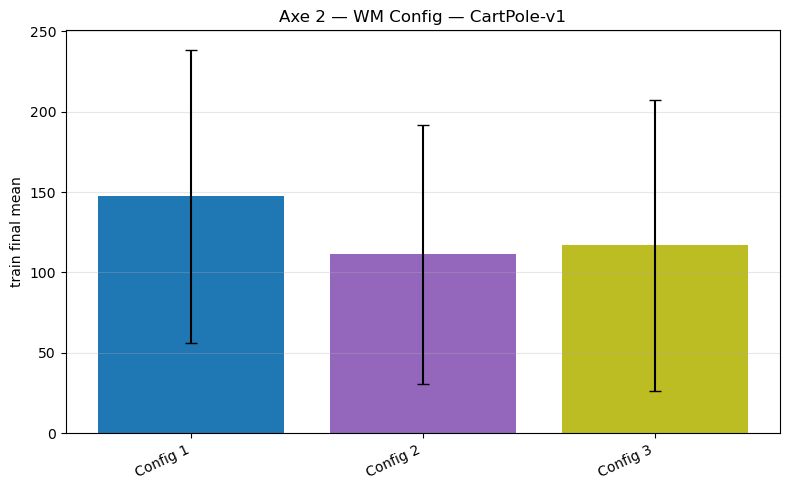

  /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/plots/ablation_wm_config_CartPole_v1.png


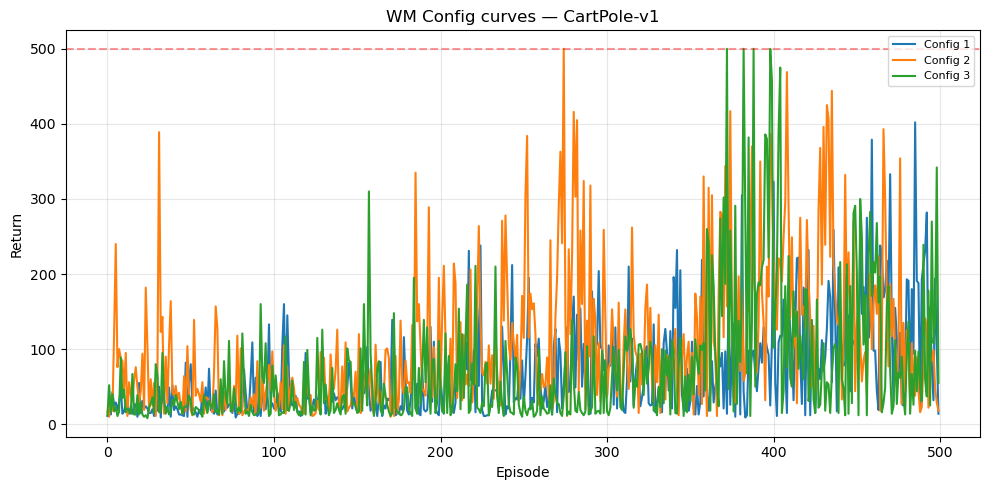

  /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/plots/ablation_wm_config_curves_CartPole_v1.png


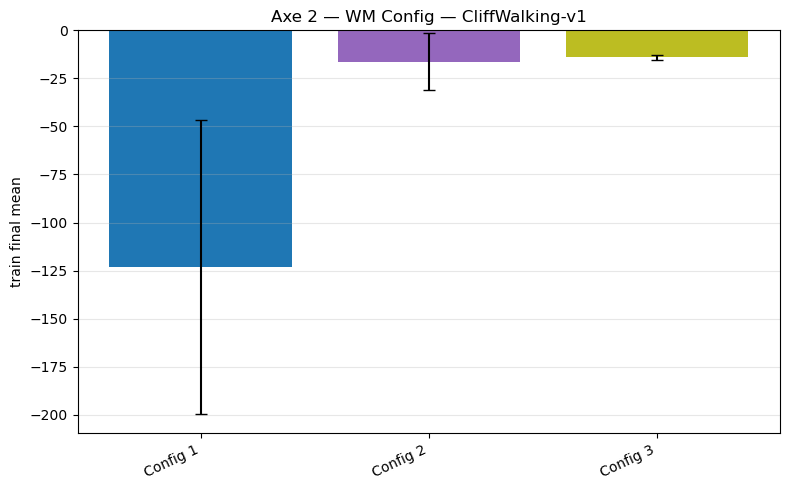

  /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/plots/ablation_wm_config_CliffWalking_v1.png


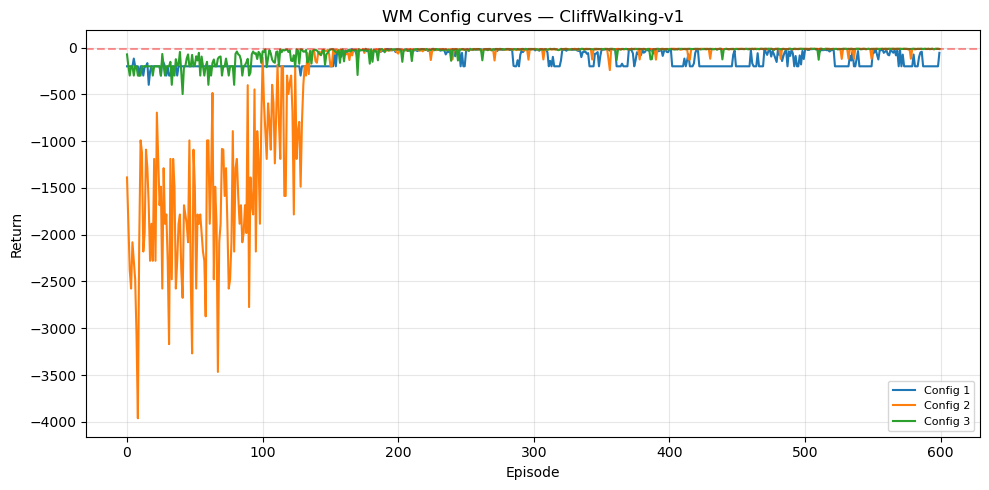

  /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/plots/ablation_wm_config_curves_CliffWalking_v1.png
✅ Saved → /Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/results/ablation_world_model_config.json


PosixPath('/Users/nouhailanokry/Desktop/REINFORCEMENT LEARNING/Projet/PHASE 5: ABLATION STUDY/results/ablation_world_model_config.json')

In [4]:
for env in ENVS:
    entries = list(results.get(env, {}).values())
    if entries:
        plot_bar_comparison(entries, f"Axe 2 — WM Config — {env}",
                            f"ablation_wm_config_{env.replace('-','_')}.png")
        curves = {e["label"]: {"reward_curves": [e.get("rewards", [])]} for e in entries if e.get("rewards")}
        if curves:
            plot_learning_curves(curves, f"WM Config curves — {env}",
                                 f"ablation_wm_config_curves_{env.replace('-','_')}.png",
                                 solve_threshold=ENV_SPECS[env]["solve_threshold"])

save_ablation_result("ablation_world_model_config", results)
